## 📘 Quadratically Constrained Integer Programming Benchmark: **QPLIB_3562**

The **QPLIB_3562** instance is an integer quadratically constrained optimization problem from **QPLIB (Quadratic Programming Library)**, a public library of structured quadratic programming problems used for benchmarking and solver research.

This instance combines **integer decision variables** with **nonlinear constraints**, including quadratic relationships among variables. Such problems are more general than linear or purely mixed-integer linear programs and arise in contexts where discrete decisions interact with nonlinear system behavior.

🔗 QPLIB instance page: https://qplib.zib.de/QPLIB_3562.html :contentReference[oaicite:1]{index=1}

---

### 🧮 Problem Structure

According to the QPLIB statistics:

- **Total variables:** 63  
- **Binary variables:** 7  
- **General integer variables:** 56  
- **Nonlinear integer variables:** 56  
- **Nonlinear variables:** 56  
- **Objective sense:** Minimize  
- **Objective type:** Linear  
- **Linear constraints:** 35  
- **Quadratic constraints:** 7  
- **Constraint curvature:** Indefinite  
- **Solution objective value:** 15.0 (known solution)  

---

### 🧠 Mathematical Form (Abstract)

The QPLIB instances follow a general quadratically constrained form: :contentReference[oaicite:3]{index=3}

For decision vector \(x \in \mathbb{R}^n\) with a subset \(\mathcal{Z} \subseteq \{1,\ldots,n\}\) restricted to integers:

$$
\begin{aligned}
\min\quad & b^0 x + q^0 \\
\text{s.t.}\quad & c^i_l \;\leq\; \frac{1}{2}x^\top Q^i x + b^i x \;\leq\; c^i_u,\quad i = 1,\ldots,m \\
& l_j \;\leq\; x_j \;\leq\; u_j,\quad j = 1,\ldots,n \\
& x_j \in \mathbb{Z}\quad \forall j \in \mathcal{Z}. \\
\end{aligned}
$$

- The objective has **no quadratic component** for this instance (only linear terms).  
- The **nonlinear constraints** are quadratic and indefinite — meaning they are not convex, and the feasible region may be nonconvex.  
- All variables are integer, (binary variables and general integer variables), making the problem an **MIQCP (Mixed-Integer Quadratically Constrained Program)**.

---

### 🧩 Why This Instance Is Interesting

The **QPLIB_3562** instance is valuable for solver benchmarking because:

- It contains a mix of **quadratic constraints** and **integer variables**, requiring both nonlinear and combinatorial optimization strategies.
- The **indefinite curvature** of the constraints (i.e., not all quadratic parts are convex) makes the problem **nonconvex**, challenging many standard QP and MIQCP solvers.
- It illustrates how continuous, integer, and discrete nonlinear structures interact in practical optimization settings.

---

### 📊 Known Solution

The published solution point for this instance yields an objective value of **15.0**.  
This value can serve as a benchmark to verify that the solver implementation and model formulation are correct.
---

### 🗂 What This Notebook Analyzes

In this notebook, we will:

1. **Load the QPLIB_3562 problem** (converted to a solvable format, e.g., `.lp` or `.gms`) into Gurobi.
2. Apply appropriate solver settings to handle **nonconvex MIQCPs** (e.g., `NonConvex=2`).
3. Use **callbacks** to track solver progress:
   - incumbent objective values
   - best bound evolution
   - relative MIP/QC gap
   - node counts and solve time
4. Create **visualizations** such as:
   - objective vs time (log scale)
   - gap vs time
   - bound tightening vs node count
5. Interpret solver behavior on a challenging quadratically constrained optimization problem.

---

### 📌 Notes

- Solving MIQCPs with nonconvex constraints generally requires careful solver settings and potentially reformulations (e.g., McCormick envelopes or spatial branch-and-bound).
- Even though the objective is linear, the quadratic constraints make this instance inherently nonlinear and discrete, combining the difficulty of both MIQP and MINLP problems.


Read LP format model from file /content/QPLIB_3562.lp
Reading time = 0.00 seconds
obj: 35 rows, 63 columns, 175 nonzeros
Set parameter OutputFlag to value 1
Set parameter NonConvex to value 2
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Non-default parameters:
NonConvex  2

Optimize a model with 35 rows, 63 columns and 175 nonzeros (Min)
Model fingerprint: 0x398e6317
Model has 14 linear objective coefficients
Model has 7 quadratic constraints
Variable types: 0 continuous, 63 integer (7 binary)
Coefficient statistics:
  Matrix range     [1e+00, 8e+02]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [1e-01, 1e+00]
  Bounds range     [1e+00, 2e+01]
  RHS range        [6e+00, 3e+03]
  QRHS range       [5e+00, 2e+01]
Presolve time: 0.00s
Presolved: 140 rows, 113 columns, 420 nonzeros
Presolved model

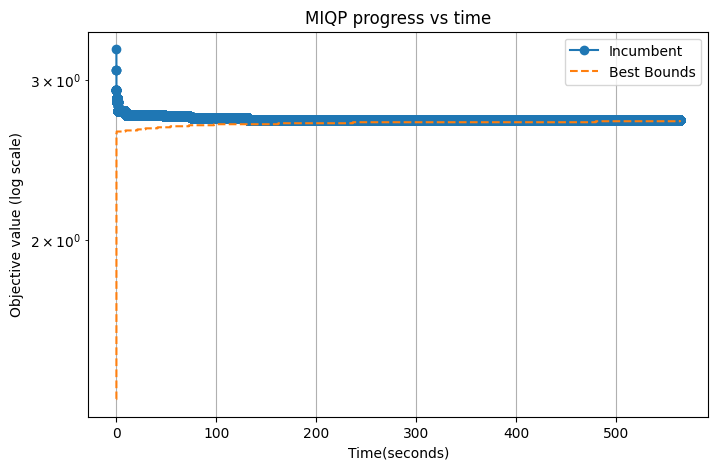

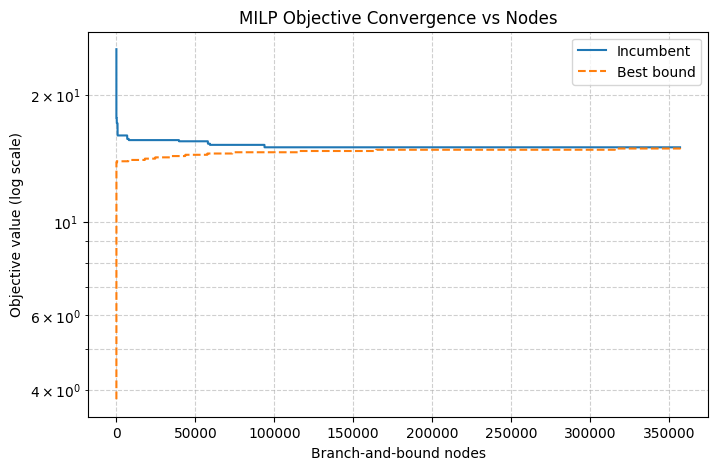

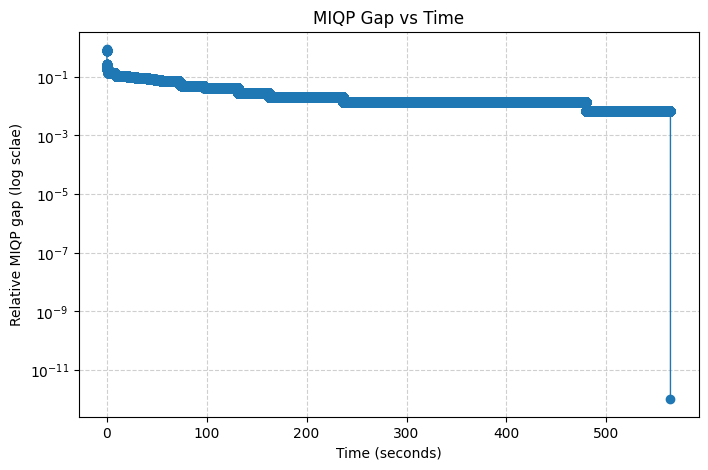

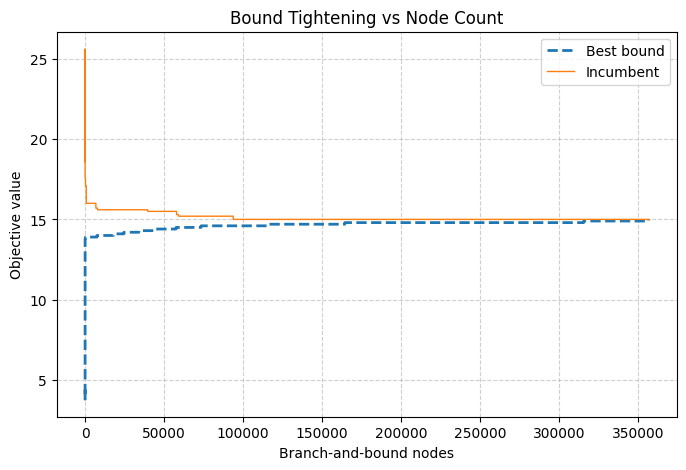

In [10]:
!pip -q install gurobipy
import gurobipy as gp
from gurobipy import GRB
from matplotlib import pyplot as plt
import numpy as np
import os

model_path = "/content/QPLIB_3562.lp"

if not os.path.exists(model_path):
   raise FileNotFoundError(f"Not found: {model_path}")

# reading optimization model from the file: QPLIB_3562.lp.txt
model = gp.read(model_path)
model.Params.OutputFlag = 1 # to print solver output
model.Params.NonConvex = 2

# store run time, bounds, objective function value for visualization of solver performance
times = []
nodes = []
incumbents = []
bounds = [] # Gurobi uses branch-and-bound method for integer/mixed integer programming problems
events = []

# this function is triggered when there is a feasible solution

def cb(model, where):
    if where == GRB.Callback.MIPSOL:
       t = model.cbGet(GRB.Callback.RUNTIME)
       n = model.cbGet(GRB.Callback.MIPSOL_NODCNT)
       obj = model.cbGet(GRB.Callback.MIPSOL_OBJ)
       bnd = model.cbGet(GRB.Callback.MIPSOL_OBJBND)

       times.append(t)
       nodes.append(n)
       incumbents.append(obj)
       bounds.append(bnd)
       events.append("MIPSOL")

    elif where == GRB.Callback.MIP:
       t = model.cbGet(GRB.Callback.RUNTIME)
       n = model.cbGet(GRB.Callback.MIP_NODCNT)
       obj_best = model.cbGet(GRB.Callback.MIP_OBJBST)
       obj_bnd = model.cbGet(GRB.Callback.MIP_OBJBND)

       if obj_best< GRB.INFINITY:
          times.append(t)
          nodes.append(n)
          incumbents.append(obj_best)
          bounds.append(obj_bnd)
          events.append("MIP")

model.optimize(cb) # run the solve with callback

print("Collected points")
print("Status", model.status)
if model.SolCount > 0:
   print("OPtimal value of Objective function", model.ObjVal)
   model.write("/content/solution.sol")
   model.write("/content/model_parsed.lp")

# plot objective vs time
plt.figure(figsize = (8,5))
plt.plot(times, np.log(incumbents), marker = "o", label = "Incumbent")
plt.plot(times, np.log(bounds), linestyle = "--", label = "Best Bounds")
plt.yscale("log")
plt.xlabel("Time(seconds)")
plt.ylabel("Objective value (log scale)")
plt.title("MIQP progress vs time")
plt.grid(True)
plt.legend()
plt.show()

# objective function vs nodes
plt.figure(figsize = (8,5))
plt.plot(nodes, incumbents, label = "Incumbent")
plt.plot(nodes, bounds, linestyle = "--", label = "Best bound")
plt.yscale("log")
plt.xlabel("Branch-and-bound nodes")
plt.ylabel("Objective value (log scale)")
plt.title("MILP Objective Convergence vs Nodes")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.show()

# visualiztion of how integrality gas reduces as optimization advances
t = np.asarray(times, dtype =  float)
inc = np.asarray(incumbents, dtype = float)
bnd = np.asarray(bounds, dtype = float)

# keep only finite values
mask = np.isfinite(t) & np.isfinite(inc) & np.isfinite(bnd)
t, inc, bnd = t[mask], inc[mask], bnd[mask]

# relative gap
eps = 1e-12
gap = (inc - bnd)/np.maximum(np.abs(inc),eps)
gap = np.maximum(gap,eps) # to avoid infinite or negative values

order = np.argsort(t)
t, gap = t[order], gap[order]

plt.figure(figsize =(8,5))
plt.plot(t,gap, marker = "o", linewidth = 1)
plt.yscale("log")
plt.xlabel("Time (seconds)")
plt.ylabel("Relative MIQP gap (log sclae)")
plt.title("MIQP Gap vs Time")
plt.grid(True, which = "both", linestyle = "--", alpha = 0.6)
plt.show()

# plotting node count vs best bound

n = np.asarray(nodes, dtype = float)
inc = np.asarray(incumbents, dtype = float)
bnd = np.asarray(bounds, dtype = float)

mask = np.isfinite(n) & np.isfinite(inc) & np.isfinite(bnd)
n, inc, bnd = n[mask], inc[mask], bnd[mask]

# sort by node count
order = np.argsort(n)
n, inc, bnd = n[order], inc[order], bnd[order]

plt.figure(figsize = (8,5))
# Best bound vs nodes (main request)
plt.plot(n, bnd, linestyle="--", linewidth=2, label="Best bound")

# Optional: include incumbent for context
plt.plot(n, inc, linewidth=1, label="Incumbent")

plt.xlabel("Branch-and-bound nodes")
plt.ylabel("Objective value")
plt.title("Bound Tightening vs Node Count")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()



